# CUSTOMER SEGMENTATION USING K-MEANS

## Import Relevant Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Load Raw Dataset

In [2]:
raw_data = pd.read_csv ('Customer_segment_raw.csv')
raw_data.head()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month
0,3.403026,-2.234183,133.511170,3.913474
1,8.430104,1.414093,1130.001675,11.162908
2,6.515294,-0.300569,762.091608,9.141014
3,5.419352,-0.166831,488.846695,7.520996
4,5.116834,-0.688150,120.734730,4.890441


In [3]:
data=raw_data.copy()

## Exploratory Data Analysis

In [4]:
data.describe()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.667633,0.035267,534.337114,7.702787
std,1.858004,0.972098,442.919783,5.103375
min,0.143625,-2.706022,14.976836,-0.212954
25%,4.179185,-0.706792,161.579317,3.266388
50%,5.592034,0.007725,421.640529,6.835214
75%,7.194681,0.777683,727.190641,10.948469
max,10.628579,2.964528,2021.029550,25.286731


In [5]:
data.isnull().sum()

Customer_Satisfaction     0
Customer_Loyalty_Score    0
Annual_Spending_USD       0
Visits_Per_Month          0
dtype: int64

In [6]:
data.duplicated().sum()

0

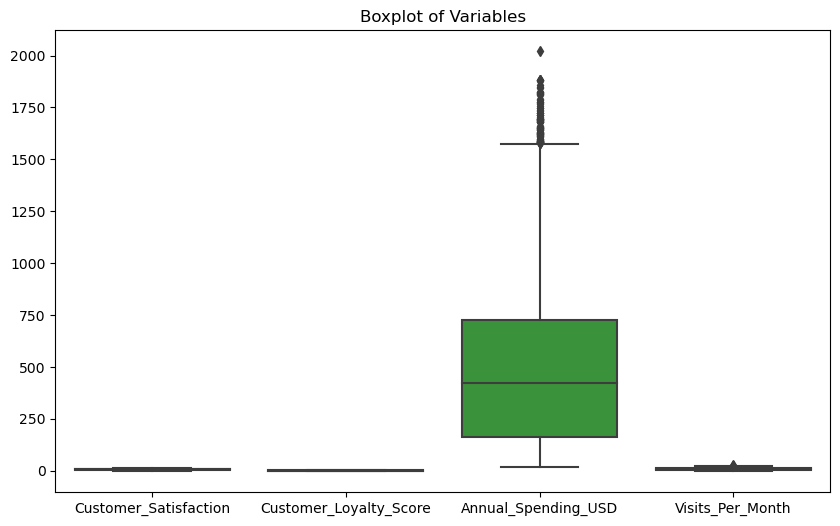

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.title("Boxplot of Variables")
plt.show()

In [8]:
Q1 = data['Annual_Spending_USD'].quantile(0.25)
Q3 = data['Annual_Spending_USD'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_1 = data[(data['Annual_Spending_USD'] >= lower_bound) &
                         (data['Annual_Spending_USD'] <= upper_bound)]

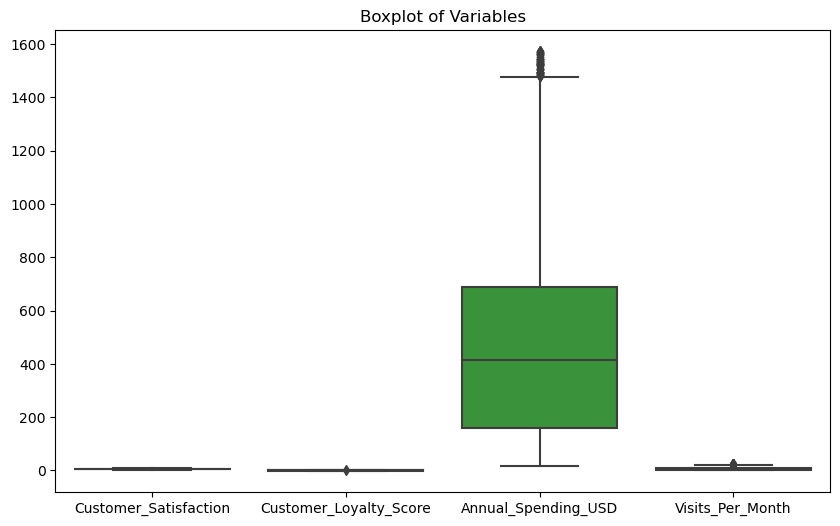

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data_1)
plt.title("Boxplot of Variables")
plt.show()

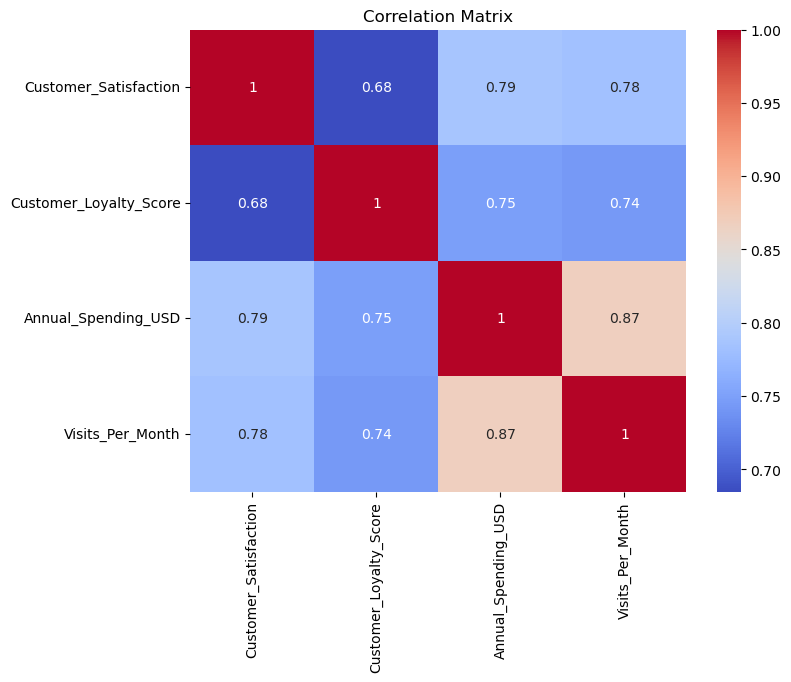

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(data_1.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
scaler = RobustScaler()

scaled = scaler.fit_transform(data_1)

scaled_data = pd.DataFrame(scaled, columns=data_1.columns)

scaled_data.head()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month
0,-0.724319,-1.520896,-0.530626,-0.372013
1,0.969932,0.975602,1.359541,0.599426
2,0.324594,-0.197734,0.661680,0.328488
3,-0.044767,-0.106217,0.143383,0.111403
4,-0.146723,-0.462954,-0.554861,-0.241097


## Dimensionality reduction with PCA

In [12]:
pca = PCA(n_components=2)

pca_dataset = pca.fit_transform(scaled_data)

pca_data = pd.DataFrame(pca_dataset, columns=["PC1","PC2"])

In [13]:
print(pca.explained_variance_ratio_)

[0.83593062 0.07390681]


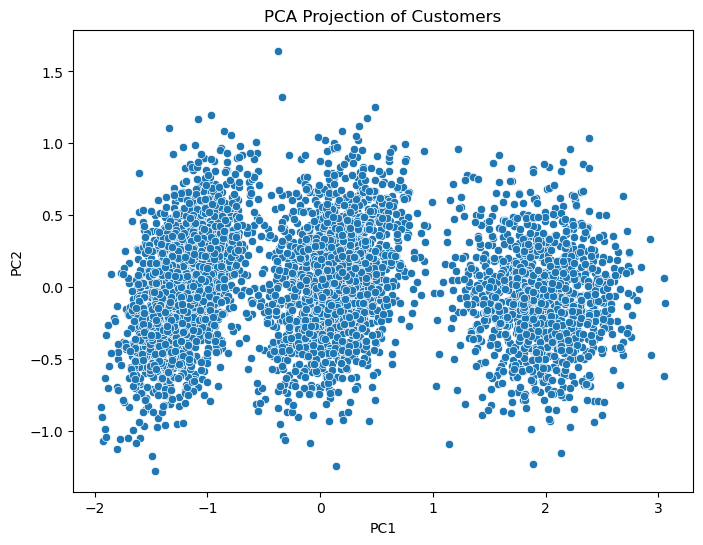

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data["PC1"],
    y=pca_data["PC2"]
)

plt.title("PCA Projection of Customers")
plt.show()

## K-Means Clustering

In [15]:
inertia = []

k_range = range(1,10)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    
    inertia.append(kmeans.inertia_)

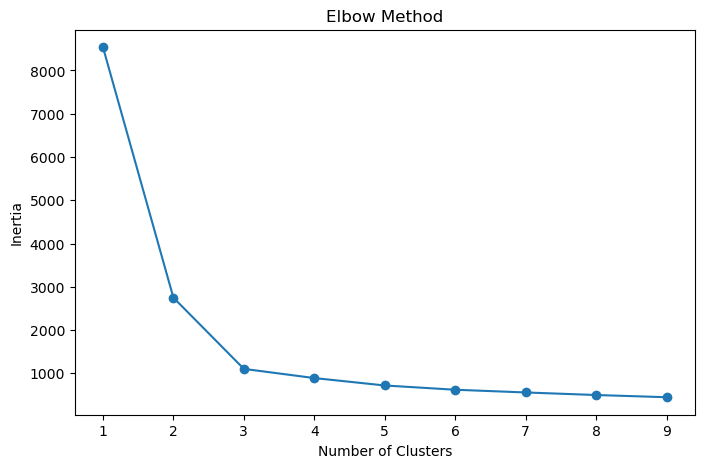

In [16]:
plt.figure(figsize=(8,5))

plt.plot(k_range, inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [17]:
data_1=data_1.reset_index(drop=True)

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(pca_data)

pca_data["Cluster"] = clusters
data_1["Cluster"] = clusters
data_1.head()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month,Cluster
0,3.403026,-2.234183,133.511170,3.913474,0
1,8.430104,1.414093,1130.001675,11.162908,1
2,6.515294,-0.300569,762.091608,9.141014,2
3,5.419352,-0.166831,488.846695,7.520996,2
4,5.116834,-0.688150,120.734730,4.890441,0


In [19]:
pca_data.head()

,PC1,PC2,Cluster
0,-1.696701,-0.836183,0
1,1.781677,0.132655,1
2,0.419167,-0.459126,2
3,-0.118582,-0.074243,2
4,-0.918259,-0.090030,0


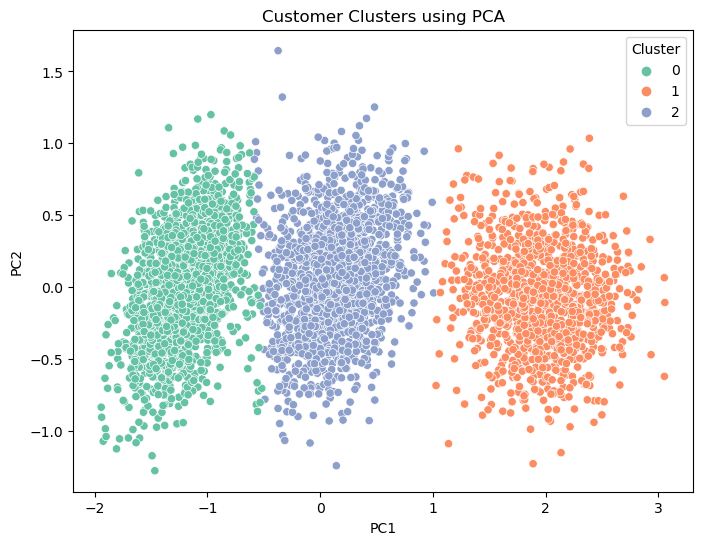

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data["PC1"],
    y=pca_data["PC2"],
    hue=pca_data["Cluster"],
    palette="Set2"
)

plt.title("Customer Clusters using PCA")

plt.show()

In [21]:
score = silhouette_score(pca_data[["PC1","PC2"]], pca_data["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6003410025871365


In [22]:
cluster_profile = data_1.groupby("Cluster").mean()

cluster_profile

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month
Cluster,,,,
0,3.977646,-0.801169,153.087113,3.018359
1,7.974803,1.199271,1179.291221,14.986502
2,6.023367,0.196797,499.974256,8.044087


In [23]:
data_cluster=data_1.copy()

In [24]:
data_cluster.head()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month,Cluster
0,3.403026,-2.234183,133.511170,3.913474,0
1,8.430104,1.414093,1130.001675,11.162908,1
2,6.515294,-0.300569,762.091608,9.141014,2
3,5.419352,-0.166831,488.846695,7.520996,2
4,5.116834,-0.688150,120.734730,4.890441,0


In [25]:
data_cluster.loc[:, 'Cluster'] = data_cluster['Cluster'].map({0:'Low Value Customers',1:'High Value Customers', 2:'Regular Customers'})

In [26]:
data_cluster.head()

,Customer_Satisfaction,Customer_Loyalty_Score,Annual_Spending_USD,Visits_Per_Month,Cluster
0,3.403026,-2.234183,133.511170,3.913474,Low Value Customers
1,8.430104,1.414093,1130.001675,11.162908,High Value Customers
2,6.515294,-0.300569,762.091608,9.141014,Regular Customers
3,5.419352,-0.166831,488.846695,7.520996,Regular Customers
4,5.116834,-0.688150,120.734730,4.890441,Low Value Customers


In [27]:
data_cluster.to_csv("customer_segments_results.csv", index=False)